# Task 1: Laying the Foundation for Analysis

## Brent Oil Prices Change Point Analysis

### Project Objective

The objective of this project is to analyze historical Brent crude oil prices and identify significant market changes caused by economic, geopolitical, and industry events.

The analysis workflow includes:

1. Loading and understanding the Brent oil price dataset.
2. Performing data quality assessment.
3. Cleaning and preparing the data.
4. Exploring historical price trends.
5. Identifying volatility patterns and possible structural changes.
6. Connecting price movements with major global events.

The final goal is to build a foundation for statistical modeling and change point detection.

## Data Analysis Workflow

The analysis follows these major steps:

### Step 1: Data Loading
- Import Brent oil price data.
- Convert date fields into proper datetime format.
- Validate dataset structure.

### Step 2: Data Quality Assessment
- Check missing values.
- Identify duplicated records.
- Validate data types.
- Detect abnormal values.

### Step 3: Exploratory Data Analysis
- Analyze descriptive statistics.
- Understand price distribution.
- Examine historical trends.

### Step 4: Visualization
- Plot historical Brent prices.
- Analyze price movements.
- Identify periods of high volatility.

### Step 5: Event Research
Collect important economic and geopolitical events that may explain major price changes.

### Step 6: Modeling Preparation
Prepare cleaned data for:
- Change point detection
- Statistical modeling
- Forecasting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

import sys

# Add project root to python path

sys.path.append("../")


print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Import project modules

from src.data_loader import (
    load_brent_data,
    convert_date_column
)

from src.preprocessing import (
    create_price_features
)

from src.eda import (
    dataset_overview,
    summary_statistics,
    price_range
)

from src.visualization import (
    plot_price_history,
    plot_price_distribution,
    plot_price_change
)


print("Project modules imported successfully")

Project modules imported successfully


In [3]:
DATA_PATH = "../data/BrentOilPrices.csv"


df = load_brent_data(
    DATA_PATH
)


df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [4]:
# Dataset shape
print(
    "Dataset Shape:"
)

print(df.shape)

Dataset Shape:
(9011, 2)


In [5]:
# Display column names

df.columns

Index(['Date', 'Price'], dtype='str')

In [6]:
# Convert Date column

df = convert_date_column(
    df,
    date_column="Date"
)


df.head()


c:\Users\edenteklehaimanot\Downloads\brent-oil-change-point-analysis\notebooks\..\src\data_loader.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_column] = pd.to_datetime(


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


In [9]:
overview = dataset_overview(
    df
)
overview

{'rows': 9011,
 'columns': 2,
 'column_names': ['Date', 'Price'],
 'missing_values': {'Date': 0, 'Price': 0},
 'duplicates': np.int64(0)}

In [11]:
summary_statistics(
    df
)

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [12]:
df = create_price_features(
    df
)


df.head()

,Date,Price,Price_Change,Rolling_Mean_30
0,1987-05-20,18.63,NaN,NaN
1,1987-05-21,18.45,-0.18,NaN
2,1987-05-22,18.55,0.10,NaN
3,1987-05-25,18.60,0.05,NaN
4,1987-05-26,18.63,0.03,NaN


In [13]:
price_range(df)

{'minimum_price': np.float64(9.1),
 'maximum_price': np.float64(143.95),
 'average_price': np.float64(48.42078237709466)}

In [14]:
df.describe()

,Date,Price,Price_Change,Rolling_Mean_30
count,9011,9011.000000,9010.000000,8982.000000
mean,2005-02-10 23:46:53.760958,48.420782,0.008320,48.394248
min,1987-05-20 00:00:00,9.100000,-16.600000,10.004333
25%,1996-03-20 12:00:00,19.050000,-0.390000,19.062583
50%,2005-02-02 00:00:00,38.570000,0.020000,39.265833
75%,2014-01-09 12:00:00,70.090000,0.450000,70.341333
max,2022-11-14 00:00:00,143.950000,10.450000,135.606667
std,NaN,32.860110,1.216227,32.721627


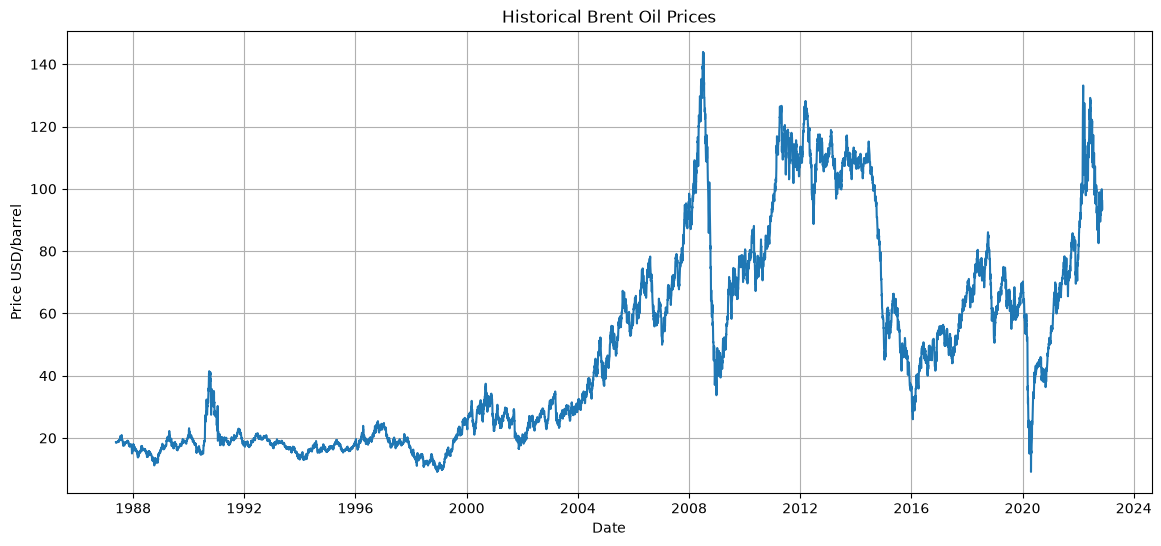

In [15]:
plot_price_history(
    df
)

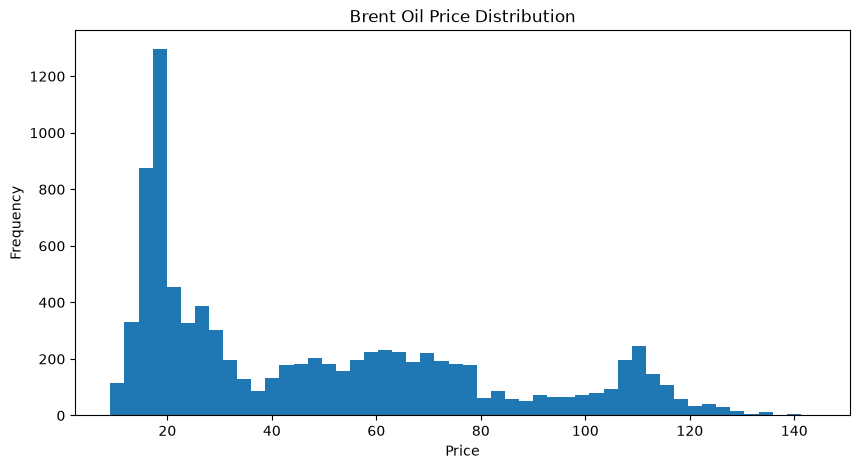

In [17]:
plot_price_distribution(df)

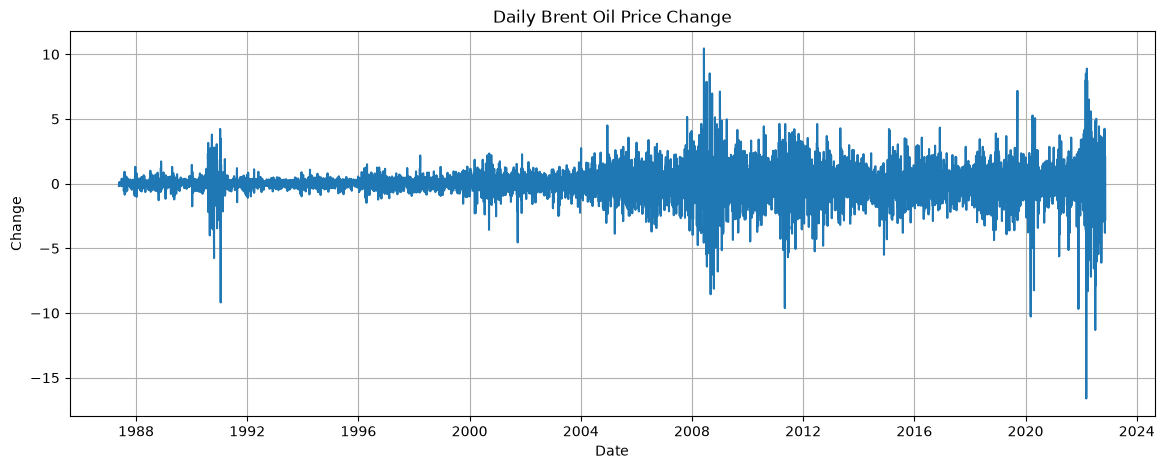

In [19]:
plot_price_change(df)

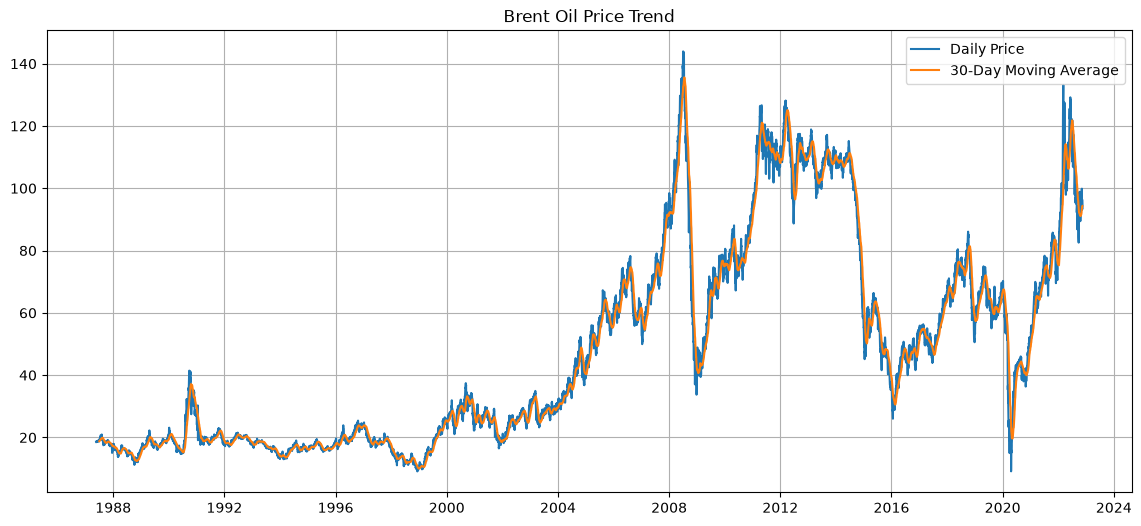

In [20]:
plt.figure(figsize=(14,6))


plt.plot(
    df["Date"],
    df["Price"],
    label="Daily Price"
)


plt.plot(
    df["Date"],
    df["Rolling_Mean_30"],
    label="30-Day Moving Average"
)


plt.title(
    "Brent Oil Price Trend"
)


plt.legend()

plt.grid(True)

plt.show()

In [21]:
df.describe()

,Date,Price,Price_Change,Rolling_Mean_30
count,9011,9011.000000,9010.000000,8982.000000
mean,2005-02-10 23:46:53.760958,48.420782,0.008320,48.394248
min,1987-05-20 00:00:00,9.100000,-16.600000,10.004333
25%,1996-03-20 12:00:00,19.050000,-0.390000,19.062583
50%,2005-02-02 00:00:00,38.570000,0.020000,39.265833
75%,2014-01-09 12:00:00,70.090000,0.450000,70.341333
max,2022-11-14 00:00:00,143.950000,10.450000,135.606667
std,NaN,32.860110,1.216227,32.721627


In [23]:
missing_values = df.isnull().sum()

missing_values

Date                0
Price               0
Price_Change        1
Rolling_Mean_30    29
dtype: int64

In [24]:
OUTPUT_PATH = "../data/brent_processed.csv"


df.to_csv(
    OUTPUT_PATH,
    index=False
)


print(
    "Processed dataset saved successfully:"
)

print(
    OUTPUT_PATH
)

Processed dataset saved successfully:
../data/brent_processed.csv
